# Problem Set 1 — Building a Strategic Portfolio

**Total: 9 points**

In this problem set you will build a complete, data-driven investment portfolio using modern portfolio theory. You will work through six analytical tasks:

| Task | Topic | Points |
|------|-------|--------|
| 1 | Jarque-Bera Normality Test | 2 |
| 2 | Investment Opportunity Set & Efficient Frontier | 2 |
| 3 | Tangency Portfolio & Optimal Complete Portfolio | 2 |
| 4 | Risk Decomposition via OLS Regression | 2 |
| 5 | Expected vs. Realized Performance | 0.5 |
| 6 | Visualize Portfolio Weights | 0.5 |

### Assets
- **SPY** – U.S. Equities (S&P 500)
- **QQQ** – Nasdaq-100 (Growth/Tech)
- **^GDAXI** – German Stocks (DAX)
- **VNQ** – Real Estate (REITs)
- **TLT** – Long-term U.S. Government Bonds
- **GLD** – Gold

### Autograder contract
The autograder looks for **exactly these names** in your notebook. Do not rename them.

**Functions:** `test_normality`, `portfolio_return`, `portfolio_volatility`, `portfolio_sharpe`,
`calculate_efficient_frontier`, `find_tangency_portfolio`, `optimal_complete_portfolio`,
`perform_risk_analysis`, `plot_tangency_weights`

**Variables:** `tangency_weights`, `y_star`, `expected_perf`, `expected_risk`,
`realized_perf`, `realized_risk`, `portfolio_fig`

In [1]:
pip install yfinance


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from scipy.optimize import minimize
from scipy.stats import skew, kurtosis, chi2

In [3]:
# ── Data acquisition (pre-filled) ──────────────────────────────────────────
tickers        = sorted(["SPY", "GLD", "VNQ", "TLT", "QQQ", "^GDAXI"])
start_date     = "2010-01-01"
end_date       = "2024-12-31"
risk_free_rate = 0.02

def fetch_asset_data(tickers, start_date, end_date):
    data = yf.download(tickers, start=start_date, end=end_date, progress=False)
    if "Adj Close" in [c[0] for c in data.columns]:
        prices = data["Adj Close"]
    else:
        prices = data["Close"]
    prices.columns = [c.replace(".", "_") for c in prices.columns]
    return prices.dropna()

asset_prices   = fetch_asset_data(tickers, start_date, end_date)
market_prices  = fetch_asset_data(["SPY"], start_date, end_date)
returns        = asset_prices.pct_change().dropna()
returns_market = market_prices.pct_change().dropna()

print("Asset prices loaded:", asset_prices.shape)
asset_prices.head()

Asset prices loaded: (3708, 6)


,GLD,QQQ,SPY,TLT,VNQ,^GDAXI
Date,,,,,,
2010-01-04,109.800003,40.290779,84.796387,55.928650,23.552101,6048.299805
2010-01-05,109.699997,40.290779,85.020821,56.289875,23.525673,6031.859863
2010-01-06,111.510002,40.047756,85.080711,55.536301,23.483362,6034.330078
2010-01-07,110.820000,40.073792,85.439850,55.629745,23.737133,6019.359863
2010-01-08,111.370003,40.403637,85.724159,55.604839,23.562670,6037.609863


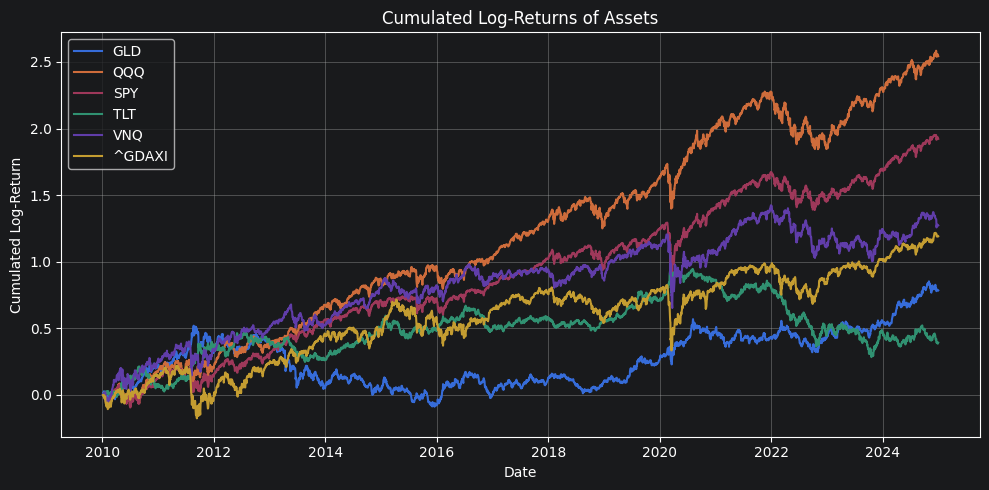

In [4]:
# ── Cumulative log-returns (pre-filled) ────────────────────────────────────
log_returns          = np.log(asset_prices / asset_prices.shift(1)).dropna()
cumulative_log_returns = log_returns.cumsum()

plt.figure(figsize=(10, 5))
for ticker in cumulative_log_returns.columns:
    plt.plot(cumulative_log_returns.index, cumulative_log_returns[ticker], label=ticker)
plt.title("Cumulated Log-Returns of Assets")
plt.xlabel("Date")
plt.ylabel("Cumulated Log-Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Task 1 — Jarque-Bera Normality Test  `[2 pts]`

The **Jarque-Bera (JB) test** checks whether returns are normally distributed using skewness $S$ and (Pearson) kurtosis $K$:

$$JB = \frac{n}{6}\left(S^2 + \frac{(K-3)^2}{4}\right)$$

Under the null hypothesis of normality, $JB \sim \chi^2(2)$, so the p-value is $1 - F_{\chi^2(2)}(JB)$.

**Your job:** Implement `test_normality(returns)` so that it returns a `pd.DataFrame` with one row per asset and columns for the JB statistic, p-value, skewness, and kurtosis.

**Hints:**
- Use `stats.skew(data)` and `stats.kurtosis(data, fisher=False)` (Pearson, normal = 3)
- p-value: `1 - chi2.cdf(jb_stat, df=2)`

In [5]:
def test_normality(returns):
    """
    Jarque-Bera normality test for each asset.

    Parameters
    ----------
    returns : pd.DataFrame  (daily returns, one column per asset)

    Returns
    -------
    pd.DataFrame with index = asset names and columns:
        'JB Statistic', 'p-value', 'Skewness', 'Kurtosis'
    """
    results = {}
    for asset in returns.columns:
        data = returns[asset].dropna()
        n    = len(data)

        # ── YOUR CODE HERE ──────────────────────────────────────────────────
        skew_val = stats.skew(data)   # skewness
        kurt_val = stats.kurtosis(data, fisher=False)   # Pearson kurtosis (fisher=False)
        jb_stat  = (n / 6) * (skew_val**2 + (0.25 * ((kurt_val - 3)**2)))  # JB formula
        p_value  = 1 - stats.chi2.cdf(jb_stat, df=2)   # p-value from chi2(df=2)
        # ────────────────────────────────────────────────────────────────────

        results[asset] = {
            "JB Statistic": jb_stat,
            "p-value":      p_value,
            "Skewness":     skew_val,
            "Kurtosis":     kurt_val,
        }
    return pd.DataFrame(results).T


normality_results = test_normality(returns)
normality_results

,JB Statistic,p-value,Skewness,Kurtosis
GLD,3033.908050,0.0,-0.399641,7.359288
QQQ,5582.360314,0.0,-0.356784,8.969284
SPY,17837.273602,0.0,-0.524934,13.694883
TLT,1840.554542,0.0,0.057178,6.450088
VNQ,38779.720815,0.0,-0.754633,18.773118
^GDAXI,7903.236202,0.0,-0.311418,10.125974


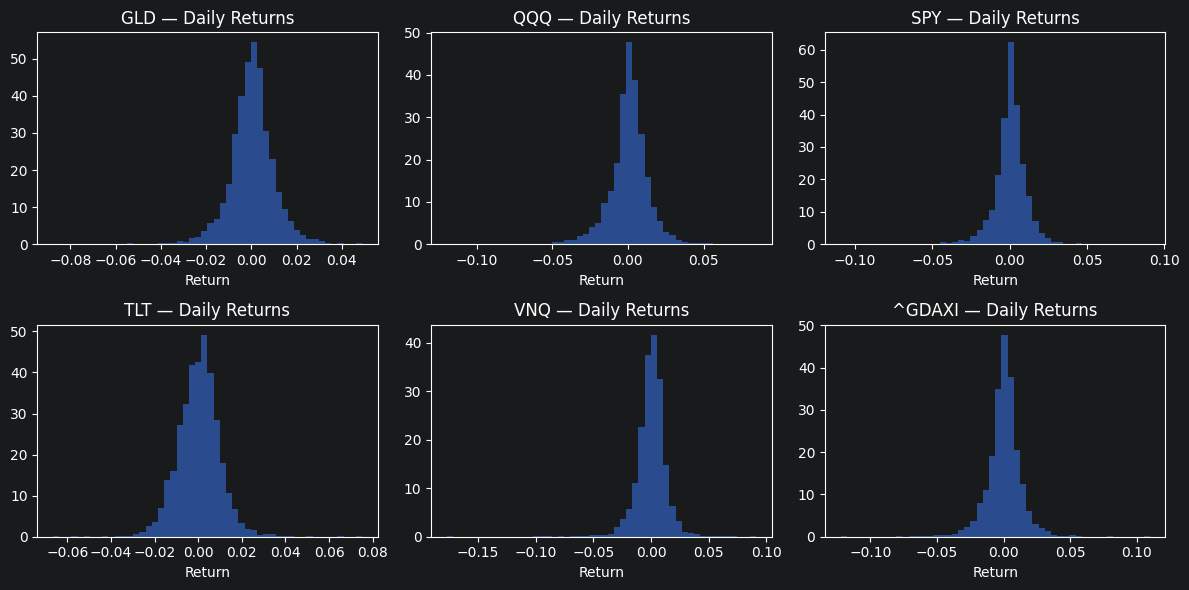

In [6]:
# Return distribution histograms (pre-filled)
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
for i, asset in enumerate(returns.columns):
    axes[i].hist(returns[asset], bins=50, density=True, alpha=0.6)
    axes[i].set_title(f"{asset} — Daily Returns")
    axes[i].set_xlabel("Return")
plt.tight_layout()
plt.show()

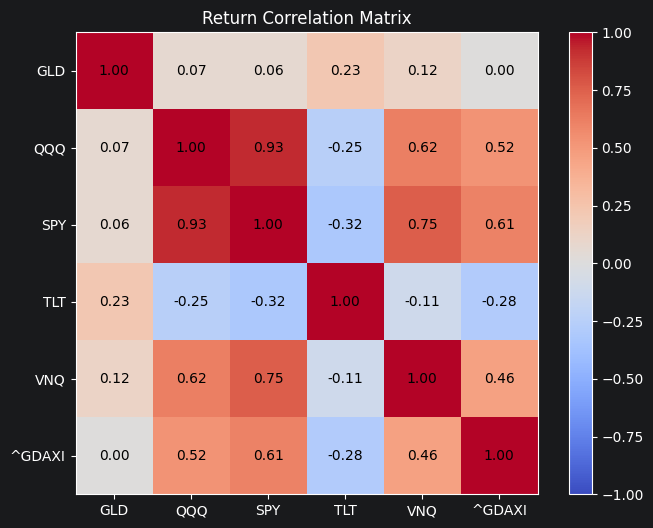

In [7]:
# Correlation matrix (pre-filled)
correlation_matrix = returns.corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(im, ax=ax)
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", color="black")
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns)
ax.set_yticklabels(correlation_matrix.columns)
plt.title("Return Correlation Matrix")
plt.show()

---
## Task 2 — Investment Opportunity Set & Efficient Frontier  `[2 pts]`

**Mean-Variance framework:**
$$\mu_p = \mathbf{w}^\top \boldsymbol{\mu}, \quad \sigma_p = \sqrt{\mathbf{w}^\top \Sigma \mathbf{w}}$$

The **Efficient Frontier** is the set of portfolios that minimise $\sigma_p$ for each target $\mu_p$.

**Your job:**
1. Implement `portfolio_return(weights)`, `portfolio_volatility(weights)`, `portfolio_sharpe(weights)`.
2. Implement `calculate_efficient_frontier(mu, Sigma)` that returns a list of weight arrays, one per frontier point.

**Constraints for optimisation:** weights sum to 1, no short-selling (≥ 0), max 40 % per asset.

In [8]:
# TODO: compute annualised expected returns
mu    = returns.mean() * 252
# TODO: compute annualised covariance matrix
Sigma = returns.cov() * 252


def portfolio_return(weights):
    """Expected portfolio return: w^T mu."""
    weights_array = np.asarray(weights)
    return np.dot(weights_array, mu)


def portfolio_volatility(weights):
    """Portfolio volatility: sqrt(w^T Sigma w)."""
    weights_array = np.asarray(weights)
    variance = weights_array.T @ Sigma @ weights_array
    return float(np.sqrt(variance))


def portfolio_sharpe(weights):
    """Sharpe ratio: (return - rf) / volatility."""
    volatility = portfolio_volatility(weights)
    if volatility == 0: # we cannot divide with 0, in order to accept the zero volatility situation I defined it as negative infinity
        return -np.inf

    return float(portfolio_return(weights) - risk_free_rate) / volatility


def calculate_efficient_frontier(mu, Sigma):
    """
    Calculate portfolio weights on the efficient frontier.

    Parameters
    ----------
    mu : array-like
        Expected returns of the assets.

    Sigma : array-like
        Covariance matrix of asset returns.

    Returns
    -------
    weights_list : list
        A list of portfolio weight vectors. Each weight vector should represent
        one portfolio on the efficient frontier.

    Notes
    -----
    You should complete this function.

    The efficient frontier is built by finding portfolios with minimum risk
    for different target return levels.

    Portfolio return:
        w' * mu

    Portfolio variance:
        w' * Sigma * w

    Portfolio volatility:
        sqrt(w' * Sigma * w)
    """

    # Step 1:
    # Convert mu into a one-dimensional NumPy array.
    # This avoids shape problems such as (n, 1) instead of (n,).
    # Hint: use np.asarray(...).ravel()
    mu_arr = np.asarray(mu).ravel()

    # Step 2:
    # Convert Sigma into a NumPy array.
    # Sigma should be a square covariance matrix with shape (n_assets, n_assets).
    sig_arr = np.asarray(Sigma)

    # Step 3:
    # Get the number of assets.
    # Hint: this should be the length of mu_arr.
    n = len(mu_arr)

    # Step 4:
    # Define portfolio weight bounds.
    # In this assignment, each asset weight should be between 0% and 40%.
    # Hint: create one bound tuple for each asset.
    bounds = [(0, 0.4) for _ in range(n)]

    # Step 5:
    # Define the full-investment constraint.
    # The sum of all portfolio weights must be equal to 1.
    #
    # Mathematical condition:
    #     sum(w_i) = 1
    #
    # Hint:
    #     Use a dictionary with:
    #     {"type": "eq", "fun": ...}
    eq_sum = {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }

    # Step 6:
    # Find the minimum-variance portfolio.
    # This portfolio has the lowest possible volatility under the constraints.
    #
    # Objective:
    #     minimize sqrt(w' Sigma w)
    #
    # Hint:
    #     Use scipy.optimize.minimize()
    #     Start with equal weights: np.ones(n) / n
    mv_res = minimize(
        fun=portfolio_volatility,
        x0=np.ones(n) / n,
        method="SLSQP",
        bounds=bounds,
        constraints=eq_sum

    )

    # Step 7:
    # If the minimum-variance optimization is successful,
    # calculate its expected return.
    # Otherwise, choose a reasonable fallback value.
    mv_ret = portfolio_return(mv_res.x) if mv_res.success else mu_arr.min()

    # Step 8:
    # Choose a starting point for the next optimizations.
    # If the minimum-variance optimization worked, use its weights.
    # Otherwise, use equal weights.
    x0 = mv_res.x if mv_res.success else np.ones(n) / n

    # Step 9:
    # Create a range of target returns.
    # The efficient frontier can be built by solving one optimization
    # problem for each target return.
    #
    # Hint:
    #     Use np.linspace(start_return, end_return, number_of_points)
    targets = np.linspace(mv_ret, mu_arr.max(), 20)

    # Step 10:
    # Create an empty list where the efficient frontier portfolio weights
    # will be stored.
    weights_list = []

    # Step 11:
    # Loop over the target returns.
    # For each target return, solve a constrained optimization problem:
    #
    # Minimize:
    #     portfolio volatility
    #
    # Subject to:
    #     1. sum(weights) = 1
    #     2. portfolio return = target return
    #     3. each weight is between 0 and 0.4
    for target in targets:
        # Define and solve the optimization problem for this target return.
        res = minimize(
            fun=portfolio_volatility,
            x0=x0,
            method="SLSQP",
            bounds=bounds,
            constraints=[eq_sum,
            {   "type": "eq",
                "fun": lambda weights, target=target: portfolio_return(weights) - target
            }]
        )

        # If the optimization is successful, save the portfolio weights.
        # You may also update x0 to the latest successful solution.
        if res.success:
         weights_list.append(res.x)
         x0 = res.x

    # Step 12:
    # Return the list of efficient frontier portfolio weights.
    #return weights_list

    # This error is here to remind you that the function is incomplete.
    # Remove it after completing the implementation.
    return weights_list


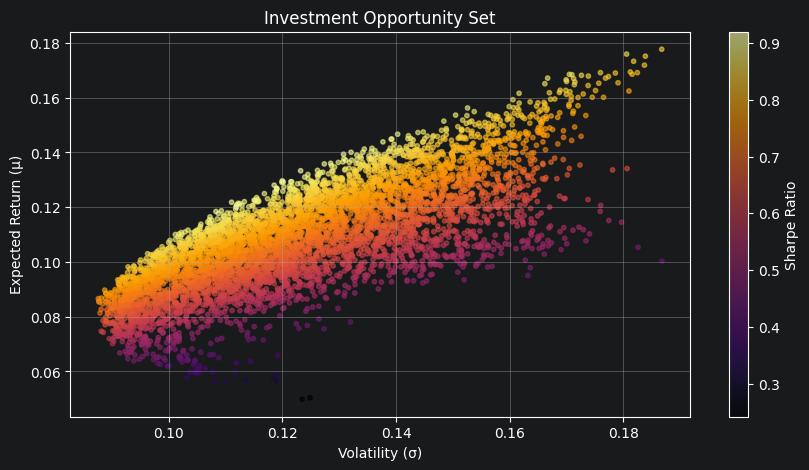

In [9]:
# Investment Opportunity Set scatter (pre-filled — run after implementing above)
np.random.seed(42)
n_portfolios = 5000
all_weights  = np.random.dirichlet(np.ones(len(mu)), size=n_portfolios)
ret_list     = [portfolio_return(w)    for w in all_weights]
vol_list     = [portfolio_volatility(w) for w in all_weights]
sr_list      = [(r - risk_free_rate) / v for r, v in zip(ret_list, vol_list)]

plt.figure(figsize=(10, 5))
plt.scatter(vol_list, ret_list, c=sr_list, cmap="inferno", s=10, alpha=0.6)
plt.colorbar(label="Sharpe Ratio")
plt.title("Investment Opportunity Set")
plt.xlabel("Volatility (σ)")
plt.ylabel("Expected Return (μ)")
plt.grid(True)
plt.show()

---
## Task 3 — Tangency Portfolio & Optimal Complete Portfolio  `[2 pts]`

The **Tangency Portfolio** maximises the Sharpe Ratio:
$$\text{Sharpe} = \frac{\mu_p - R_f}{\sigma_p}$$

The **Optimal Complete Portfolio** mixes the tangency portfolio with the risk-free asset based on risk aversion $A$:
$$y^* = \min\!\left(\frac{\mu_p - R_f}{A \cdot \sigma_p^2},\; 1\right)$$

**Your job:**
1. Implement `find_tangency_portfolio(mu, Sigma, risk_free_rate)` — return the weight array.
2. Implement `optimal_complete_portfolio(tangency_weights, mu, Sigma, rf=0.02, A=9)` — return only `y*`.
3. Compute and store `tangency_weights` and `y_star` at module level.

In [10]:


# ── Task 3: Tangency Portfolio & Optimal Complete Portfolio ───────────────

def find_tangency_portfolio(mu, Sigma, risk_free_rate):
    """
    Find the tangency portfolio.

    The tangency portfolio is the portfolio with the highest Sharpe ratio.

    Parameters
    ----------
    mu : array-like
        Expected returns of the assets.

    Sigma : array-like
        Covariance matrix of asset returns.

    risk_free_rate : float
        Risk-free rate used in the Sharpe ratio.

    Returns
    -------
    weights : NumPy array
        Portfolio weights of the tangency portfolio.

    Notes
    -----
    Sharpe ratio:

        Sharpe = (portfolio return - risk-free rate) / portfolio volatility

    Since scipy.optimize.minimize() minimizes a function, we minimize the
    negative Sharpe ratio.
    """

    # Step 1:
    # Convert mu into a one-dimensional NumPy array.
    # This avoids shape problems such as (n, 1) instead of (n,).
    mu_arr = np.asarray(mu)

    # Step 2:
    # Convert Sigma into a NumPy array.
    # Sigma should be a square covariance matrix.
    sig_arr = np.asarray(Sigma)

    # Step 3:
    # Get the number of assets.
    n = len(mu_arr)

    # Step 4:
    # Define the objective function.
    # The objective should return the negative Sharpe ratio.
    #
    # Portfolio return:
    #     w' * mu
    #
    # Portfolio volatility:
    #     sqrt(w' * Sigma * w)
    #
    # Negative Sharpe ratio:
    #     - (portfolio return - risk_free_rate) / portfolio volatility
    def neg_sharpe(w):
        # TODO: calculate portfolio return
        ret = float(w @ mu_arr)

        # TODO: calculate portfolio volatility
        vol = float(np.sqrt(w.T @ sig_arr @ w))

      #  if portfolio_volatility == 0: return np.inf
        # TODO: return the negative Sharpe ratio
        return -((ret - risk_free_rate) / vol)

    # Step 5:
    # Define the initial guess.
    # A common starting point is an equally weighted portfolio.
    x0 = np.ones(n) / n

    # Step 6:
    # Define the bounds.
    # In this assignment, each asset weight should be between 0% and 40%.
    bounds = [(0, 0.4) for _ in range(n)]

    # Step 7:
    # Define the full-investment constraint.
    # The sum of all portfolio weights must be equal to 1.
    constraint = {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }

    # Step 8:
    # Use scipy.optimize.minimize() to find the portfolio weights
    # that minimize the negative Sharpe ratio.
    res = minimize(
        fun = neg_sharpe, #we want to minimize the negative sharpe so that we actually find maximum
        x0 = x0, #our start point is the equal distribution
        method="SLSQP",
        bounds=bounds,
        constraints=constraint
    )

    if res.success:
        return res.x
    else:
        return x0

def optimal_complete_portfolio(tangency_weights, mu, Sigma, rf=0.02, A=9):
    """
    Calculate the optimal allocation to the risky tangency portfolio.

    Parameters
    ----------
    tangency_weights : array-like
        Weights of the tangency portfolio.

    mu : array-like
        Expected returns of the assets.

    Sigma : array-like
        Covariance matrix of asset returns.

    rf : float, optional
        Risk-free rate. Default is 0.02.

    A : float, optional
        Risk-aversion parameter. Default is 9.

    Returns
    -------
    y_star : float
        Fraction of total wealth invested in the risky tangency portfolio.

    Notes
    -----
    The optimal risky allocation is:

        y* = (E[R_p] - r_f) / (A * sigma_p^2)

    where:

        E[R_p]     = expected return of the tangency portfolio
        r_f        = risk-free rate
        A          = risk-aversion parameter
        sigma_p^2  = variance of the tangency portfolio

    If y* = 1, the investor puts 100% in the risky tangency portfolio.
    If y* = 0.5, the investor puts 50% in the risky tangency portfolio
    and 50% in the risk-free asset.
    """

    # Step 1:
    # Convert inputs into NumPy arrays.
    weights = np.asarray(tangency_weights)
    mu_arr = np.asarray(mu)
    sig_arr = np.asarray(Sigma)

    # Step 2:
    # Calculate the expected return of the tangency portfolio.
    #
    # Formula:
    #     rp = w' * mu
    rp = float(np.dot(weights, mu))

    # Step 3:
    # Calculate the variance of the tangency portfolio.
    #
    # Formula:
    #     variance = w' * Sigma * w
    variance_p = portfolio_volatility(weights)**2

    # Step 4:
    # Calculate y_star.
    #
    # Formula:
    #     y_star = (rp - rf) / (A * variance_p)
    y_star = (rp - rf) / (A * variance_p)

    # Step 5:
    # Optional: restrict y_star to a maximum of 1.0
    # This means the investor cannot invest more than 100% in the risky portfolio.
    
    y_star = float(np.clip(y_star, 0, 1))

    # Step 6:
    # Return the optimal risky allocation.
    # TODO: replace the line below with your implementation.
    return y_star




# Store at module level (required by autograder)
tangency_weights = find_tangency_portfolio(mu, Sigma, risk_free_rate)
y_star           = optimal_complete_portfolio(tangency_weights, mu, Sigma)

print("Tangency weights:")
for t, w in zip(tickers, tangency_weights):
    print(f"  {t:8s}: {w*100:.2f}%")
print(f"\ny* (allocation to tangency portfolio): {y_star*100:.2f}%")

Tangency weights:
  GLD     : 14.31%
  QQQ     : 40.00%
  SPY     : 14.47%
  TLT     : 27.98%
  VNQ     : 0.00%
  ^GDAXI  : 3.23%

y* (allocation to tangency portfolio): 90.95%


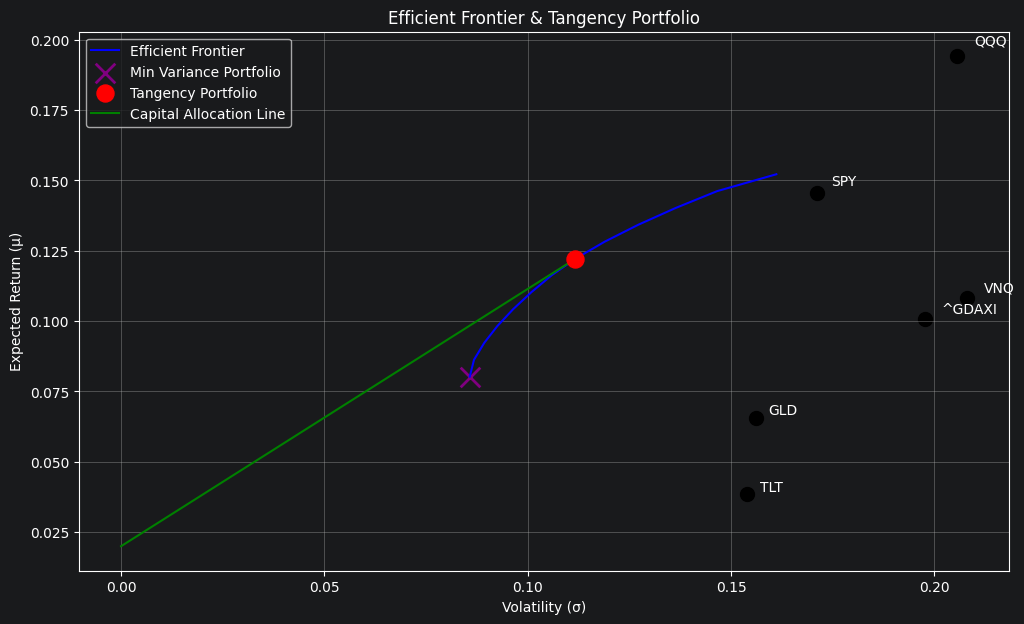

Tangency: E[R]=12.21%  σ=11.17%  Sharpe=0.914


In [11]:
# Efficient Frontier + Tangency Portfolio plot (pre-filled)
efficient_weights      = calculate_efficient_frontier(mu, Sigma)
efficient_returns      = [portfolio_return(w)    for w in efficient_weights]
efficient_volatilities = [portfolio_volatility(w) for w in efficient_weights]

tangency_return     = portfolio_return(tangency_weights)
tangency_volatility = portfolio_volatility(tangency_weights)

plt.figure(figsize=(12, 7))
plt.plot(efficient_volatilities, efficient_returns, "b-", label="Efficient Frontier")

min_vol_idx = np.argmin(efficient_volatilities)
plt.scatter(efficient_volatilities[min_vol_idx], efficient_returns[min_vol_idx],
            marker="x", s=200, c="purple", linewidths=2, label="Min Variance Portfolio")

asset_vols = np.sqrt(np.diag(np.asarray(Sigma)))
for i, ticker in enumerate(tickers):
    plt.scatter(asset_vols[i], float(np.asarray(mu).ravel()[i]), c="k", s=100)
    plt.text(asset_vols[i]*1.02, float(np.asarray(mu).ravel()[i])*1.02, ticker, fontsize=10)

plt.scatter(tangency_volatility, tangency_return, c="r", s=150, zorder=5, label="Tangency Portfolio")

x_cal = np.linspace(0, max(efficient_volatilities)*1.1, 100)
y_cal = risk_free_rate + (tangency_return - risk_free_rate) / tangency_volatility * x_cal
plt.plot(x_cal[x_cal <= tangency_volatility], y_cal[x_cal <= tangency_volatility],
         "g-", label="Capital Allocation Line")

plt.xlabel("Volatility (σ)")
plt.ylabel("Expected Return (μ)")
plt.title("Efficient Frontier & Tangency Portfolio")
plt.legend()
plt.grid(True)
plt.show()

print(f"Tangency: E[R]={tangency_return*100:.2f}%  σ={tangency_volatility*100:.2f}%  "
      f"Sharpe={(tangency_return-risk_free_rate)/tangency_volatility:.3f}")

---
## Task 4 — Risk Decomposition via OLS Regression  `[2 pts]`

Decompose portfolio returns into systematic (market) and idiosyncratic components:
$$R_p - R_f = \alpha + \beta(R_m - R_f) + \varepsilon$$

Risk decomposition:
$$\sigma_p^2 = (\beta \cdot \sigma_m)^2 + \sigma_\varepsilon^2$$

Return decomposition (annualised):
$$\text{Total Return} = \underbrace{\beta \cdot E[R_m - R_f] \cdot 252 + R_f}_{\text{Systematic}} + \underbrace{\alpha \cdot 252}_{\text{Idiosyncratic}}$$

**Your job:** Implement `perform_risk_analysis(portfolio_weights, returns)` returning a dict with all keys listed below.

In [12]:
# ── Task 4: OLS Risk Decomposition ───────────────────────────────────────

def perform_risk_analysis(portfolio_weights, returns):
    """
    Perform risk decomposition using an OLS regression.

    The goal of this function is to decompose the portfolio return and risk into:

    1. Systematic component:
       The part explained by market movements.

    2. Idiosyncratic component:
       The portfolio-specific part that is not explained by the market.

    Parameters
    ----------
    portfolio_weights : array-like
        Portfolio weights, for example the tangency portfolio weights.

    returns : pandas DataFrame
        Daily asset returns.

    Returns
    -------
    risk_table : dict
        Dictionary containing beta, alpha, R-squared, return decomposition,
        and risk decomposition.

    Notes
    -----
    The regression model is:

        Portfolio excess return = alpha + beta * Market excess return + error

    In formula form:

        R_p - r_f = alpha + beta * (R_m - r_f) + epsilon

    where:
        R_p     = portfolio return
        R_m     = market return
        r_f     = risk-free rate
        alpha   = idiosyncratic return component
        beta    = market exposure
        epsilon = residual / unexplained part
    """

    # Step 1:
    # Convert portfolio weights into a NumPy array.
    # This avoids shape and multiplication errors.
    weights = np.asarray(portfolio_weights)

    # Step 2:
    # Calculate daily portfolio returns.
    #
    # Hint:
    # Multiply each asset return by its portfolio weight,
    # then sum across columns.
    #
    # Formula:
    #     R_p,t = sum(w_i * R_i,t)
    portfolio_returns = (returns @ weights)

    # Step 3:
    # Define the market return.
    #
    # In this assignment, SPY is used as the market proxy.
    # A market proxy is an asset used to represent the overall market.
    #
    # Hint:
    # Use the SPY column from the returns DataFrame.
    market_returns = returns["SPY"]

    # Step 4:
    # Convert the annual risk-free rate into a daily risk-free rate.
    #
    # Hint:
    # If risk_free_rate is annual, divide it by 252 trading days.
    daily_rf = risk_free_rate / 252

    # Step 5:
    # Calculate excess returns.
    #
    # Excess return means return above the risk-free rate.
    #
    # Portfolio excess return:
    #     R_p - r_f
    #
    # Market excess return:
    #     R_m - r_f
    portfolio_excess = portfolio_returns - daily_rf
    market_excess = market_returns - daily_rf

    # Step 6:
    # Align the portfolio and market excess return series.
    #
    # This is important because both series must have the same dates
    # before running the regression.
    idx = portfolio_excess.index.intersection(market_excess.index)

    portfolio_excess = portfolio_excess.loc[idx]

    market_excess = market_excess.loc[idx]

    # Step 7:
    # Prepare the regression input.
    #
    # statsmodels requires us to add a constant term.
    # The constant represents alpha.
    #
    # Hint:
    # Use sm.add_constant(...)
    X = sm.add_constant(market_excess)

    # Step 8:
    # Run the OLS regression.
    #
    # OLS means Ordinary Least Squares.
    #
    # Regression model:
    #     portfolio_excess = alpha + beta * market_excess + error
    #
    # Hint:
    # Use sm.OLS(y, X).fit()
    model = sm.OLS(portfolio_excess, X).fit()

    # Step 9:
    # Extract beta and alpha from the regression result.
    #
    # alpha is the intercept.
    # beta is the slope coefficient on the market excess return.
    beta = model.params["SPY"]
    alpha = model.params["const"]

    # Step 10:
    # Calculate annualized systematic return.
    #
    # Systematic return is the part explained by market exposure.
    #
    # Formula:
    #     beta * mean(market excess return) * 252 + risk_free_rate
    systematic_return = beta * market_excess.mean() * 252 + risk_free_rate

    # Step 11:
    # Calculate annualized idiosyncratic return.
    #
    # Idiosyncratic return is the annualized alpha.
    #
    # Formula:
    #     alpha * 252
    idiosyncratic_return = alpha * 252

    # Step 12:
    # Calculate total return.
    #
    # Formula:
    #     total return = systematic return + idiosyncratic return
    total_return = systematic_return + idiosyncratic_return

    # Step 13:
    # Get regression residuals.
    #
    # Residuals are the part of portfolio excess returns
    # not explained by market excess returns.
    residuals = model.resid

    # Step 14:
    # Calculate annualized systematic risk.
    #
    # Formula:
    #     |beta| * standard deviation of market excess return * sqrt(252)
    systematic_risk = beta * market_excess.std() * np.sqrt(252)

    # Step 15:
    # Calculate annualized idiosyncratic risk.
    #
    # Formula:
    #     standard deviation of residuals * sqrt(252)
    idiosyncratic_risk = residuals.std() * np.sqrt(252)

    # Step 16:
    # Calculate total risk.
    #
    # Because systematic and idiosyncratic risk are independent components,
    # total risk is calculated using the square-root-sum-of-squares formula:
    #
    #     total risk = sqrt(systematic_risk^2 + idiosyncratic_risk^2)
    total_risk = np.sqrt((systematic_risk**2) + (idiosyncratic_risk**2))

    # Step 17:
    # Store the results in a dictionary.
    #
    # Do not change the keys unless instructed.
    # The autograder may check these names.
    risk_table = {
        "Beta (β)": beta,
        "Alpha (α)": alpha,
        "R-squared": model.rsquared ,
        "Total Return": total_return,
        "Systematic Return (β)": systematic_return,
        "Idiosyncratic Return (α)": idiosyncratic_return,
        "Total Risk": total_risk,
        "Systematic Risk (βσₘ)": systematic_risk,
        "Idiosyncratic Risk (σₑ)": idiosyncratic_risk,
    }

    # Step 18:
    # Return the dictionary with all risk-analysis results.
    # Replace the line below after completing the function.
    return risk_table


# After completing the function, run this cell to display the results.

risk_table = perform_risk_analysis(tangency_weights, returns)

pd.DataFrame.from_dict(
    risk_table,
    orient="index",
    columns=["Value"]
)

,Value
Beta (β),0.540850
Alpha (α),0.000136
R-squared,0.687668
Total Return,0.122124
Systematic Return (β),0.087844
Idiosyncratic Return (α),0.034280
Total Risk,0.111698
Systematic Risk (βσₘ),0.092626
Idiosyncratic Risk (σₑ),0.062424


---
## Task 5 — Expected vs. Realized Performance  `[0.5 pts]`

Split the data into 70 % training and 30 % test periods.

- **Expected performance** = annualised return and risk computed from the *training* covariance matrix and `tangency_weights`.
- **Realized performance** = annualised return and risk of the daily portfolio returns in the *test* period.

Store four scalars: `expected_perf`, `expected_risk`, `realized_perf`, `realized_risk`.

In [13]:
returns_period = returns.loc[start_date:end_date]
# ── YOUR CODE HERE ───────────────────────────────────────────────────────
# 1. Split returns into 70% train / 30% test (by row index, not date)
w = np.asarray(tangency_weights)
split = int(len(returns) * 0.7)
returns_train = returns[:split]
returns_test = returns[split:]


# 2. Compute expected_perf and expected_risk from training data
mu_train = returns_train.mean() * 252
Sigma_train = returns_train.cov() * 252



# 3. Compute realized_perf and realized_risk from test data
# Store results in these four variable names:
expected_perf = float(w.T @ mu_train)  # annualised expected return from training covariance
expected_risk = float(np.sqrt(w.T @ Sigma_train @ w))   # annualised expected volatility from training covariance
realized_perf = float((returns_test @ w).mean() * 252)  # annualised realised return on test set
realized_risk = float((returns_test @ w).std() * np.sqrt(252))  # annualised realised volatility on test set

print(f"Expected: return={expected_perf:.4f}  risk={expected_risk:.4f}")
print(f"Realized: return={realized_perf:.4f}  risk={realized_risk:.4f}")

Expected: return=0.1376  risk=0.1000
Realized: return=0.0861  risk=0.1352


---
## Task 6 — Visualize Portfolio Weights  `[0.5 pts]`

Implement `plot_tangency_weights(tickers, weights)` that creates a **bar chart** of the tangency portfolio weights.

Requirements (checked by autograder):
- The function **returns** a `matplotlib.figure.Figure` object.
- The figure must have a **title**, an **x-axis label**, and a **y-axis label**.
- Assign the returned figure to the module-level variable `portfolio_fig`.

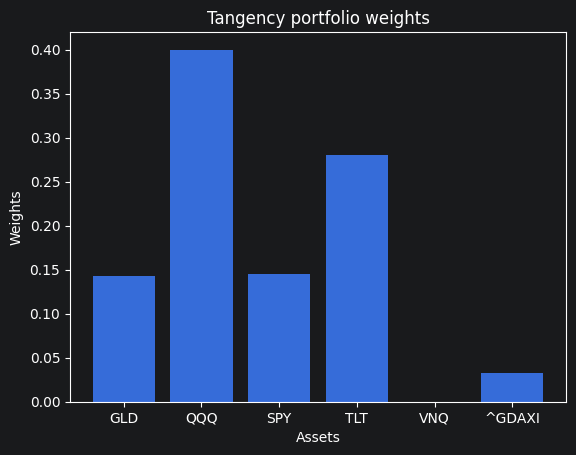

In [14]:
def plot_tangency_weights(tickers, weights):
    """
    Bar chart of tangency portfolio weights.

    Parameters
    ----------
    tickers : list of str
    weights : array-like of floats (same length as tickers)

    Returns
    -------
    matplotlib.figure.Figure  ← must return the Figure, not None
    """
    # ── YOUR CODE HERE ──────────────────────────────────────────────────────
    # Hint: use  fig, ax = plt.subplots()  and draw on ax, then return fig
    ...
    
    # TODO 1: Create a figure and axis using plt.subplots().
    # TODO 2: Plot a bar chart with tickers on the x-axis and weights on the y-axis.
    # TODO 3: Add a chart title.
    # TODO 4: Add x-axis and y-axis labels.
    # TODO 5: Adjust the layout.
    # TODO 6: Return the figure object.

    fig, ax = plt.subplots()
    ax.bar(tickers, weights)
    ax.set_title("Tangency portfolio weights")
    ax.set_xlabel("Assets")
    ax.set_ylabel("Weights")

    return fig


# Store at module level (required by autograder)
portfolio_fig = plot_tangency_weights(tickers, tangency_weights)
plt.show()